In [10]:
# 1. Loaded the loan dataset into a pandas DataFrame (`df`).
import pandas as pd 
df = pd.read_csv('loan_data.csv ')
print(df.head())

   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec  not.fully.paid  
0            0        0   

In [11]:
# 2. Inspected the dataset structure with `df.info()`.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None


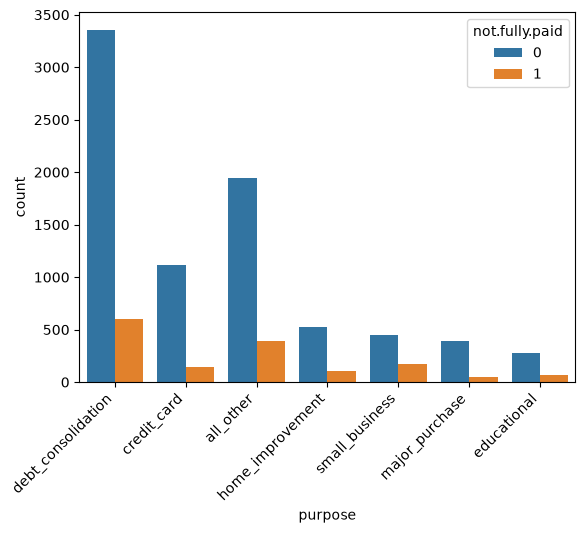

In [15]:
# 3. Visualized loan purpose distribution by target class using a count plot.

import seaborn as sns 
import matplotlib.pyplot as plt 
sns.countplot(data=df,x='purpose',hue='not.fully.paid')
plt.xticks(rotation=45,ha='right');



In [16]:
# 4. Converted categorical `purpose` values into one-hot encoded columns (`pre_df`).
pre_df = pd.get_dummies(df,columns=['purpose'],drop_first=True)
pre_df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


In [18]:
# 5. Split the data into features (`X`) and target (`y`), then created train/test sets.

from sklearn.model_selection import train_test_split
X = pre_df.drop('not.fully.paid',axis=1)
y = pre_df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.33, random_state=125
)

In [19]:
# 6. Reviewed the training features with `X_train.head()`.
print(X_train.head())

      credit.policy  int.rate  installment  log.annual.inc   dti  fico  \
602               1    0.0800       313.37       11.669929  0.00   787   
7761              0    0.1280        67.20        9.210340  3.48   647   
432               1    0.0983       804.69       11.184421  8.98   757   
386               1    0.1046       194.91       10.819778  5.06   687   
3618              1    0.0963       102.71       10.505068  0.33   732   

      days.with.cr.line  revol.bal  revol.util  inq.last.6mths  delinq.2yrs  \
602         8370.000000          0         0.0               0            0   
7761        1169.958333        571        61.9               0            1   
432         4619.041667      56842        14.4               6            0   
386         4464.000000       9516        63.4               1            0   
3618        4290.000000        496         4.1               1            0   

      pub.rec  purpose_credit_card  purpose_debt_consolidation  \
602         0 

In [20]:
# 7. Created a Gaussian Naive Bayes model.
from sklearn.naive_bayes import GaussianNB 

model = GaussianNB()

model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[5420., 997.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.84,0.16]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.322
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](18,)","['credit.policy','int.rate','installment',...,'purpose_home_improvement', 'purpose_major_purchase','purpose_small_business']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 18)","[[ 0.83, 0.12,313.66,..., 0.07, 0.05, 0.06], [ 0.65, 0.13,326.58,..., 0.07, 0.03, 0.12]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 18)","[[ 1.46, 1.32,41782.28,..., 1.38, 1.37, 1.38], [ 1.55, 1.32,46320.43,..., 1.39, 1.35, 1.43]]"


In [21]:
# 8. Trained the model on the training data.
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    f1_score, 
    classification_report,
    precision_score,
    recall_score,
)

In [22]:
# 9. Imported evaluation metrics for model assessment.
y_pred = model.predict(X_test)


In [23]:
# 10. Generated predictions on the test set.
accuray = accuracy_score(y_pred,y_test)
print("Accurary:",accuray)

Accurary: 0.8206263840556786


In [24]:
# 11. Calculated accuracy.

f1 = f1_score(y_pred, y_test, average="weighted")
print(f1)

0.8686606980013266


In [25]:
# 12. Calculated F1 score.
recall = recall_score(y_test,y_pred)
print(recall)

0.09328358208955224


In [26]:
# 13. Calculated recall and precision.
pre = precision_score(y_test,y_pred)
print(pre)

0.3816793893129771


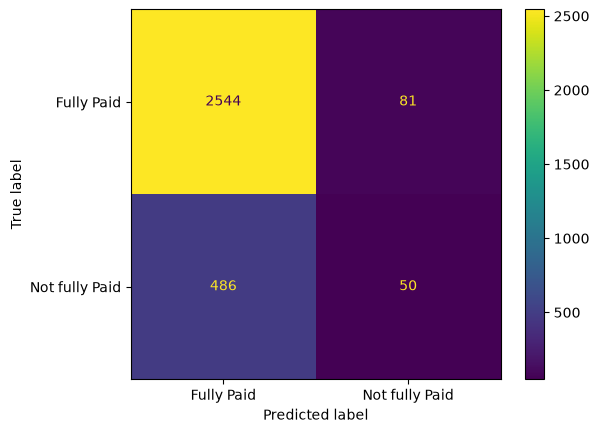

In [27]:
labels = ["Fully Paid","Not fully Paid"]
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)
disp.plot();

In [28]:
# 15. Listed the dataset column names.
print(df.columns)  

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='str')
